In [ ]:
import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [ ]:
torch.manual_seed(42) if not torch.cuda.is_available() else torch.cuda.manual_seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

## Implicit Newton Layers

As with fixed point iteration layers, the goal is to find $z^*$, where:
$$
\begin{align}
g(x, z) &= z - tanh(Wz+x) = 0 \\
z^* &= tanh(Wz+x)
\end{align}
$$

However, contrary to fixed point layers, where you iteratively search for $z^*$, now the Newton root finding method is used. This makes the method more efficient, since the Newton method uses the Jacobian to make better updates for faster convergence.
It makes the following update to continously get closer to the root:
$$
z = z - \Big(\frac{\partial g}{\partial z}\Big)^{-1} g(x,z),
$$
where the Jacobian $\frac{\partial g}{\partial z}$ is:
$$
\frac{\partial g}{\partial z} = I - diag(sech^2(Wz+x)) W
$$

Basically, the Newton Method, at each iteration, does:
1. Linearize $g(z)$ around current point: $g(z) \approx g(z_k) + J(z_k)·(z - z_k)$
2. Finding root of linearization: set to 0 and solve for z
3. This gives: $z_{k+1} = z_k - J^{-1}·g(z_k)$



In [4]:
class ImplicitNewtonLayer(nn.Module):
    def __init__(self, in_out_dim: int, tol: float=1e-4, max_iter: int=50):
        super().__init__()

        self.tol = tol
        self.max_iter = max_iter
        self.in_out_dim = in_out_dim
        self.W = nn.Linear(self.in_out_dim, self.in_out_dim, bias=False, device=device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = torch.zeros_like(x)

        self.iterations = 0

        while self.iterations < self.max_iter:
            g = z - torch.tanh(self.W(z) + x)
            self.error = torch.linalg.norm(g)

            if self.error < self.tol:
                break

            # b x n x n = (1 x) n x n - b x n (x 1) @ (1 x) n x n
            J = torch.eye(len(self.W.weight))[None, :, :] - (1 / torch.cosh(self.W(z) + x)**2)[:, :, None] * self.W.weight[None, : , :]
            # b x n = b x n - (solve( b x n x n, b x n (x 1))=(b x n (x 1)).squeeze(-1) = b x n)
            z_updated = z - torch.linalg.solve(J, g[:, :, None]).squeeze(-1)
            z = z_updated
            self.iterations += 1

        g = z - torch.tanh(self.W(z) + x)
        z[torch.linalg.norm(g, dim=1) > self.tol, :] = 0 # if convergence is not reached, prevent exploding gradients caused by residuals that are to large
        
        return z

In [5]:
layer = ImplicitNewtonLayer(25)
X = torch.randn((10, 25))
y = layer(X)
print(f"Newton layer ran {layer.iterations} iterations with an error {layer.error}")

Newton layer ran 3 iterations with an error 5.689066256309161e-06


In [7]:
class FixedPointIterationLayer(nn.Module):
    def __init__(self, in_out_dim, tol=1e-4, activation="relu", max_iter=50):
        super().__init__()
        self.linear = nn.Linear(in_out_dim, in_out_dim, bias=False)

        if activation == 'tanh':
            self.activation = torch.tanh
        else:
            self.activation = nn.functional.relu

        self.max_iter = max_iter
        self.tol = tol

    def forward(self, x):
        # Initialize z at zero
        z = torch.zeros_like(x)

        self.iterations = 0

        while self.iterations < self.max_iter:
            z_out = self.linear(z) + x
            z_out = self.activation(z_out)

            # Check convergence
            self.loss = torch.linalg.norm(z - z_out, ord=2)
            z = z_out
            self.iterations += 1

            if self.loss < self.tol:
                break

        return z

In [ ]:
# Convergence comparison
X_test = torch.randn(10, 25)

fp_layer = FixedPointIterationLayer(25, tol=1e-6)
newton_layer = ImplicitNewtonLayer(25, tol=1e-6)

_ = fp_layer(X_test)
_ = newton_layer(X_test)

print(f"Fixed Point Iteration: {fp_layer.iterations} iterations")
print(f"Newton's Method: {newton_layer.iterations} iterations")
print(f"Speedup: {fp_layer.iterations / newton_layer.iterations:.1f}x")

Fixed Point Iteration: 22 iterations
Newton's Method: 3 iterations
Speedup: 7.3x


In [72]:
def train(model: nn.Module, train_loader: DataLoader, max_epoch: int=5, lr: float=0.01) -> tuple[list[float], list[float]]:
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    total_loss = []
    total_error = []

    for _ in tqdm(range(max_epoch), desc="Training", position=0):
        loss_per_epoch = 0.0
        error_per_epoch = 0.0
        for X, y_true in tqdm(train_loader, desc="Batch", position=1, leave=False):
            X = X.to(device)
            y_true = y_true.to(device)

            opt.zero_grad()

            y_pred: torch.Tensor = model(X)
            loss = crit(y_pred, y_true)

            loss.backward()

            if sum(para.grad.isnan().sum() for para in model.parameters() if para.grad is not None) == 0:
                opt.step()

            loss_per_epoch += loss.item() * X.shape[0]

            error_per_epoch += (y_pred.argmax(dim=1) == y_true).sum().item()

        total_error.append(error_per_epoch / len(train_loader))
        total_loss.append(loss_per_epoch / len(train_loader))

    return total_error, total_loss


def test(model: nn.Module, test_loader: DataLoader) -> tuple[float, float]:
    model.eval()
    crit = nn.CrossEntropyLoss()

    total_loss = 0
    total_error = 0

    for X, y_true in tqdm(test_loader, desc="Testing"):
        X = X.to(device)
        y_true = y_true.to(device)

        y_pred: torch.Tensor = model(X)
        loss = crit(y_pred, y_true)

        total_loss += loss.item() * X.shape[0]

        total_error += (y_pred.argmax(dim=1) == y_true).sum().item()

    return total_error/ len(test_loader), total_loss / len(test_loader)

total training data points: 60000
image shape: torch.Size([1, 28, 28])
For image 0, y_true is: 7


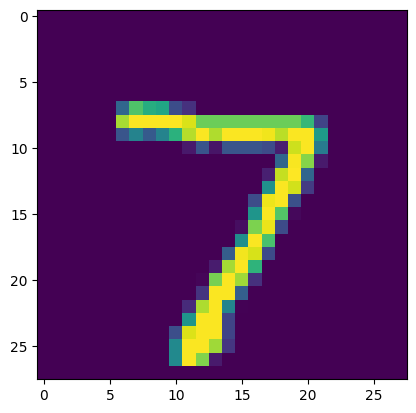

In [73]:
mnist_train = datasets.MNIST(".", train=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(".", train=False, transform=transforms.ToTensor())

print("total training data points:", len(mnist_train))
print("image shape:", mnist_train[0][0].shape)

idx = 0
print(f"For image {idx}, y_true is: {mnist_test[idx][1]}")
plt.imshow(mnist_test[0][0].view(28, 28))
plt.show()

In [74]:
train_loader = DataLoader(mnist_train, batch_size=32, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=32, shuffle=False)

In [ ]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100), # Input layer
    ImplicitNewtonLayer(100, max_iter=100), # Newton layer
    nn.Linear(100, 10) # Output layer
).to(device)

In [159]:
# training
train_error, train_loss = train(model, train_loader, max_epoch=3, lr=0.01)
print(f"Training Error: {train_error[-1]} | Training Loss: {train_loss[-1]}")

Training:   0%|          | 0/3 [00:00<?, ?it/s]

Batch:   0%|          | 0/1875 [00:00<?, ?it/s]

Batch:   0%|          | 0/1875 [00:00<?, ?it/s]

Batch:   0%|          | 0/1875 [00:00<?, ?it/s]

Training Error: 19.008 | Training Loss: 34.49921923421224


In [132]:
# testing
test_error, test_loss = test(model, test_loader)
print(f"Test Error: {test_error} | Test Loss: {test_loss}")

Testing:   0%|          | 0/313 [00:00<?, ?it/s]

Test Error: 18.162939297124602 | Test Loss: 36.23252998449551


In [157]:
idx = 126

test_pred = model(mnist_test[idx][0].view(1, -1))

print(f"test image true label: {mnist_test[idx][1]} | model prediction: {test_pred.argmax(dim=1).item()}")

test image true label: 0 | model prediction: 1
